In [1]:
from pathlib import Path

def detect_project_root() -> Path:
    try:
        # Works when running as a .py script
        return Path(__file__).resolve().parent
    except NameError:
        # Works in notebooks; choose cwd or its parent based on where `data/` is found
        cwd = Path.cwd()
        return cwd if (cwd / "data").exists() else cwd.parent

project_root = detect_project_root()
file_path = project_root / "data" / "Aiplane_BlueBook.csv"  # verify filename spelling

if not file_path.exists():
    raise FileNotFoundError(f"CSV not found at {file_path.resolve()} — check the name/location.")

import pandas as pd

df = pd.read_csv(file_path)
df["Range_NM_numeric"] = pd.to_numeric(df["Range N.M."], errors="coerce")
print(df.shape)
print("Le data contient ", df.shape[0], "lignes et ", df.shape[1], "colonnes")
print(df.head(10))

(861, 23)
Le data contient  861 lignes et  23 colonnes
                                               Model  \
0                                        15 AC Sedan   
1                                  11 CC Super Chief   
2                                        7 CCM Champ   
3                                         7 DC Champ   
4                                         7 AC Champ   
5                                        11 AC Chief   
6                  PA-60-700P Aerostar (preliminary)   
7                                   PA-602P Aerostar   
8  PA-601P pressurized Aerostar ('77 service ceil...   
9     PA-601B turbochg Aerostar (prior'80=less perf)   

                         Company Engine Type HP or lbs thr ea engine  \
0                        Aeronca      Piston                     145   
1                        Aeronca      Piston                      85   
2                        Aeronca      Piston                      90   
3                        Aeronca      Pi

In [2]:
for col in df.columns:
    print(col)

Model
Company
Engine Type
HP or lbs thr ea engine
Max speed Knots
Rcmnd cruise Knots
Stall Knots dirty
Fuel gal/lbs
All eng service ceiling
Eng out service ceiling
All eng rate of climb
Eng out rate of climb
Takeoff over 50ft
Takeoff ground run
Landing over 50ft
Landing ground roll
Gross weight lbs
Empty weight lbs
Length ft/in
Height ft/in
Wing span ft/in
Range N.M.
Range_NM_numeric


In [3]:
print(df.duplicated().sum())

0


In [4]:
print(df.isnull().sum())

Model                        0
Company                      0
Engine Type                 27
HP or lbs thr ea engine     27
Max speed Knots             70
Rcmnd cruise Knots          50
Stall Knots dirty          126
Fuel gal/lbs                54
All eng service ceiling     81
Eng out service ceiling    529
All eng rate of climb      109
Eng out rate of climb      503
Takeoff over 50ft          149
Takeoff ground run         170
Landing over 50ft          149
Landing ground roll        201
Gross weight lbs            31
Empty weight lbs            27
Length ft/in                39
Height ft/in                42
Wing span ft/in             29
Range N.M.                 103
Range_NM_numeric           105
dtype: int64


In [5]:
missing_percent = df.isnull().mean() * 100
print(missing_percent.sort_values(ascending=False))

Eng out service ceiling    61.440186
Eng out rate of climb      58.420441
Landing ground roll        23.344948
Takeoff ground run         19.744483
Landing over 50ft          17.305459
Takeoff over 50ft          17.305459
Stall Knots dirty          14.634146
All eng rate of climb      12.659698
Range_NM_numeric           12.195122
Range N.M.                 11.962834
All eng service ceiling     9.407666
Max speed Knots             8.130081
Fuel gal/lbs                6.271777
Rcmnd cruise Knots          5.807201
Height ft/in                4.878049
Length ft/in                4.529617
Gross weight lbs            3.600465
Wing span ft/in             3.368177
Engine Type                 3.135889
HP or lbs thr ea engine     3.135889
Empty weight lbs            3.135889
Model                       0.000000
Company                     0.000000
dtype: float64


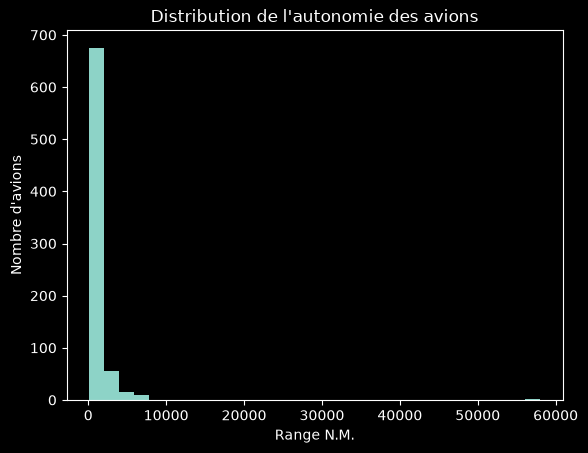

In [6]:
from matplotlib import pyplot as plt

plt.hist(df["Range_NM_numeric"].dropna(), bins=30)
plt.xlabel("Range N.M.")
plt.ylabel("Nombre d'avions")
plt.title("Distribution de l'autonomie des avions")
plt.show()